In [ ]:
# script to do the clinvar analysis on the updated dataset (20260104), including indels

In [1]:
# import packages
import os
import pandas as pd
from tqdm import tqdm
from scipy import stats
from collections import Counter
import pybedtools
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_curve
from sklearn import metrics
import numpy as np
import ptitprince as pt
import statsmodels.stats.api as sm

In [2]:
def vcf2df (file):
    pred_df = pd.read_csv(file, sep = '\t')
    # make lists of preds for new column
    # k562
    k_ref = []
    k_alt = []
    k_skew = []
    # hepg2
    h_ref = []
    h_alt = []
    h_skew = []
    # sknsh
    s_ref = []
    s_alt = []
    s_skew = []
    # parse predictions in 'INFO' column
    for i in tqdm(pred_df['INFO']):
        all_preds = i.split(';')
        # k562
        k_ref.append(float(all_preds[0].split('=')[-1]))
        k_alt.append(float(all_preds[3].split('=')[-1]))
        k_skew.append(float(all_preds[6].split('=')[-1]))
        # hepg2
        h_ref.append(float(all_preds[1].split('=')[-1]))
        h_alt.append(float(all_preds[4].split('=')[-1]))
        h_skew.append(float(all_preds[7].split('=')[-1]))
        # sknsh
        s_ref.append(float(all_preds[2].split('=')[-1]))
        s_alt.append(float(all_preds[5].split('=')[-1]))
        s_skew.append(float(all_preds[8].split('=')[-1]))
    
    df = pd.DataFrame({'chrom' : pred_df['chrom'],
                       'pos' : pred_df['pos'],
                       'id' : pred_df['id'],
                       'ref' : pred_df['ref'],
                       'alt' : pred_df['alt'],
                       'k562_ref_pred' : k_ref,
                       'k562_alt_pred' : k_alt,
                       'k562_skew_pred' : k_skew,
                       'hepg2_ref_pred' : h_ref,
                       'hepg2_alt_pred' : h_alt,
                       'hepg2_skew_pred' : h_skew,
                       'sknsh_ref_pred' : s_ref,
                       'sknsh_alt_pred' : s_alt,
                       'sknsh_skew_pred' : s_skew})
    return df

In [3]:
# define function to return emVar status
def add_emvar (pred_df,
               cell_type,
               skew_cutoff):
    # make a list for emvar status
    emvar_list = []
    for skew in pred_df[f'{cell_type}_skew_pred'].tolist():
        if abs(skew) > skew_cutoff:
            emvar_list.append(1)
        else:
            emvar_list.append(0)
    # add column to DF
    pred_df[f'{cell_type}_emvar'] = emvar_list
    return pred_df
# annotate emVars in predictions
def annotate_preds (df,
                    skew_thresh):
    # add k562 emVar status
    df = add_emvar(df,
                   'k562',
                   skew_thresh)
    # add hepg2 emVar status
    df = add_emvar(df,
                   'hepg2',
                   skew_thresh)
    # add sknsh emVar status
    df = add_emvar(df,
                   'sknsh',
                   skew_thresh)
    # add emVar any column
    df['emvar_any'] = [1 if [i,j,k].count(1) > 0 else 0 for i,j,k in zip(df['k562_emvar'],
                                                                         df['hepg2_emvar'],
                                                                         df['sknsh_emvar'])]
    return df

In [4]:
# define function to return DF of Precision and Recall of Experimental for CRE, emVar, and emVar + CRE
def empirical_precision_recall_cCREs (df):
    # split df into pathogenic and take a matched sample
    pos_df = df[df['clinsig'].isin(['Pathogenic',
                                    'Likely_pathogenic'])].copy()
    pos_df.loc[:, 'pathogenic'] = [1 for i in range(len(pos_df))]
    # get random negative sample
    neg_sample = df[~df['clinsig'].isin(['Pathogenic',
                                         'Likely_pathogenic'])].sample(len(pos_df))
    neg_sample.loc[:,'pathogenic'] = [0 for i in range(len(neg_sample))]
    # recombine df
    df = pd.concat([pos_df,
                    neg_sample])
    # make binary list of true positives
    causal_true_false = df['pathogenic']
    ### DHS ###
    dhs_hit_miss = [1 if i == 1 else 0 for i in df['dhs']]
    # calculate precision
    dhs_precision = precision_score(causal_true_false,
                                    dhs_hit_miss)
    # calculate recall
    dhs_recall = recall_score(causal_true_false,
                              dhs_hit_miss)
    # add df of precision/recall to dict
    dhs_prc = pd.DataFrame({'feature' : ['dhs'],
                            'precision' : [dhs_precision],
                            'recall' : [dhs_recall]})
    # combine all DFs
    all_prc = pd.concat([dhs_prc])

    #print(all_prc)
    return all_prc

In [5]:
# open all updated predictions
os.chdir('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/clinvar/processed_data/mpac_preds')
all_clinvar = pd.concat([vcf2df(i) for i in os.listdir() if i.endswith('.vcf')])
# break out id, clinsig
all_clinvar.loc[:, 'clinvar_id'] = [i.split(';')[0] for i in all_clinvar['id']]
# chrom:pos:ref:alt id
all_clinvar.loc[:, 'var_id'] = [i.split(';')[-1] for i in all_clinvar['id']]
# clinsig
all_clinvar.loc[:, 'clinsig'] = [i.split(';')[1] for i in all_clinvar['id']]
# label indels
all_clinvar.loc[:, 'indel'] = [1 if len(ref) > 1 or len(alt) > 1 else 0 for ref, alt in zip(all_clinvar['ref'], all_clinvar['alt'])]
# add emVars
all_clinvar = annotate_preds(all_clinvar, 0.5)
# change back to root of this analysis
# open all updated predictions
os.chdir('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/clinvar/')

100%|██████████| 18613/18613 [00:00<00:00, 276548.66it/s]


In [6]:
all_clinvar.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,sknsh_alt_pred,sknsh_skew_pred,clinvar_id,var_id,clinsig,indel,k562_emvar,hepg2_emvar,sknsh_emvar,emvar_any
0,chr4,160676,4279098;None;chr4:160676:A:G,A,G,0.019091,0.017585,-0.001506,-0.078585,-0.056816,...,-0.074077,0.002044,4279098,chr4:160676:A:G,None,0,0,0,0,0
1,chr4,295423,4305190;None;chr4:295423:T:C,T,C,0.035983,0.065579,0.029596,0.247926,0.270079,...,-0.223992,0.011168,4305190,chr4:295423:T:C,None,0,0,0,0,0
2,chr4,344137,4305389;None;chr4:344137:G:A,G,A,0.094547,0.100146,0.005598,0.008075,0.002951,...,0.087903,-0.027435,4305389,chr4:344137:G:A,None,0,0,0,0,0
3,chr4,344194,4305390;None;chr4:344194:A:C,A,C,0.154514,0.150217,-0.004297,0.112597,0.114191,...,0.128940,-0.006250,4305390,chr4:344194:A:C,None,0,0,0,0,0
4,chr4,344311,4288640;None;chr4:344311:ATT:A,ATT,A,0.111253,0.039208,-0.072045,0.177554,0.107139,...,-0.254773,-0.059673,4288640,chr4:344311:ATT:A,None,1,0,0,0,0


In [7]:
# convert the df to a BED file for adding annotations for DHS and 250bp promoter
chrom4bed = []
start4bed = []
end4bed = []
id4bed = []
for chrom, pos, id, ref, alt in zip(all_clinvar['chrom'], 
                                    all_clinvar['pos'], 
                                    all_clinvar['id'], 
                                    all_clinvar['ref'], 
                                    all_clinvar['alt']):
    # update chromosome and id lists
    chrom4bed.append(chrom)
    id4bed.append(id)
    # check the length of the variant for generating the start and stop intervals
    if len(ref) == 1 and len(alt) == 1: # SNPs
        start4bed.append(pos - 1)
        end4bed.append(pos)
    elif len(ref) < len(alt): # Insertions
        start4bed.append(pos)
        end4bed.append(pos)
    else: # Deletions
        start4bed.append(pos)
        end4bed.append(pos + len(ref) - 1)
    
all_clinvar_bed = pybedtools.BedTool.from_dataframe(pd.DataFrame({0 : chrom4bed,
                                                                  1 : start4bed,
                                                                  2 : end4bed,
                                                                  3 : id4bed}).drop_duplicates()).sort()
# open mueleman dhs tsv
mueleman_dhs_tsv = pd.read_csv('raw_data/ENCFF503GCK.tsv', sep = '\t', low_memory=False)
# convert df to bed file
mueleman_dhs_bed = pybedtools.BedTool.from_dataframe(
    pd.DataFrame({
        0 : mueleman_dhs_tsv['seqname'],
        1 : mueleman_dhs_tsv['start'],
        2 : mueleman_dhs_tsv['end'],
        3 : mueleman_dhs_tsv['component']
    })
)
# intersect clinvar bed with dhs
clinvar_dhs = all_clinvar_bed.intersect(mueleman_dhs_bed, wa=True).to_dataframe()
# open the promoter bed file
twoFifty_pro_bed = pybedtools.BedTool('raw_data/archive2/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.bed')
# open exon bed file
exonBED = pybedtools.BedTool('raw_data/archive2/gencode.v44.basic.annotation.exons.splice.autosomes.v2.bed')
twoFifty_pro_bed_exon_filtered = twoFifty_pro_bed.intersect(exonBED, v=True)
# interesect the clinvar bed with the promoters
clinvar_250bp = all_clinvar_bed.intersect(twoFifty_pro_bed_exon_filtered, wa=True).to_dataframe()

In [8]:
# make dictionaries of ids in dhs or promoters
# dhs
clinvar_dhs_dict = dict(zip(clinvar_dhs['name'], [1 for i in range(len(clinvar_dhs))]))
# 250bp promoter
clinvar_promoter_dict = dict(zip(clinvar_250bp['name'], [1 for i in range(len(clinvar_250bp))]))

In [9]:
# open dELS seqlet bed files
# k562
k_dELS_seqlets = pybedtools.BedTool('raw_data/repTF_k562_dELS_seqlets_01.bed')
# hepg2
h_dELS_seqlets = pybedtools.BedTool('raw_data/repTF_hepg2_dELS_seqlets_01.bed')
# sknsh
s_dELS_seqlets = pybedtools.BedTool('raw_data/repTF_sknsh_dELS_seqlets_01.bed')
# open dELS bed file
dELS_bed = pybedtools.BedTool('raw_data/GRCh38-dELS-only.bed')

In [10]:
# get the intersection of clinvar variants and seqlets
# k562
clinvar_k_seqlet = all_clinvar_bed.intersect(k_dELS_seqlets, wa=True).to_dataframe()
# hepg2
clinvar_h_seqlet = all_clinvar_bed.intersect(h_dELS_seqlets, wa=True).to_dataframe()
# sknsh
clinvar_s_seqlet = all_clinvar_bed.intersect(s_dELS_seqlets, wa=True).to_dataframe()
# intersect with distal elements
clinvar_dELS = all_clinvar_bed.intersect(dELS_bed, wa=True).to_dataframe()

In [11]:
# make dictionaries of each intersection for annotating predictions
# k562_seqlets
kSeqlet_dict = dict(zip(clinvar_k_seqlet['name'], [1 for i in range(len(clinvar_k_seqlet))]))
# hepg2_seqlets
hSeqlet_dict = dict(zip(clinvar_h_seqlet['name'], [1 for i in range(len(clinvar_h_seqlet))]))
# sknsh_seqlets
sSeqlet_dict = dict(zip(clinvar_s_seqlet['name'], [1 for i in range(len(clinvar_s_seqlet))]))
# dELS
dELS_dict = dict(zip(clinvar_dELS['name'], [1 for i in range(len(clinvar_dELS))]))

In [12]:
os.getcwd()

'/pod/2/tewhey-lab/buttsj/Variant_Effects/revision_experiments/clinvar'

In [13]:
# open gencode basic intersection
gencode_basic_filtered_vars = pd.read_csv(
    'processed_data/clinvar_exon_filtered_gencode_basic_gff.tsv',
    sep = '\t',
)
# make a dictionary
gencodeBasic_dict = dict(zip(
    gencode_basic_filtered_vars['name'],
    [1 for i in range(len(gencode_basic_filtered_vars))]
))

In [14]:
# add annotations to df
# dhs
all_clinvar.loc[:, 'dhs'] = [clinvar_dhs_dict.get(i) if i in clinvar_dhs_dict.keys() else 0 for i in all_clinvar['id']]
# 250bp promoter
all_clinvar.loc[:, '250bp_pro'] = [clinvar_promoter_dict.get(i) if i in clinvar_promoter_dict.keys() else 0 for i in all_clinvar['id']]
# k562 seqlet
all_clinvar.loc[:, 'k562_dELS_seqlet'] = [kSeqlet_dict.get(i) if i in kSeqlet_dict.keys() else 0 for i in all_clinvar['id']]
# hepg2 seqlet
all_clinvar.loc[:, 'hepg2_dELS_seqlet'] = [hSeqlet_dict.get(i) if i in hSeqlet_dict.keys() else 0 for i in all_clinvar['id']]
# sknsh seqlet
all_clinvar.loc[:, 'sknsh_dELS_seqlet'] = [sSeqlet_dict.get(i) if i in sSeqlet_dict.keys() else 0 for i in all_clinvar['id']]
# check for overlapping any seqlet
all_clinvar.loc[:, 'dELS_seqlet'] = [1 if sum([k,h,s]) > 0 else 0 for k,h,s in zip(all_clinvar['k562_dELS_seqlet'], all_clinvar['hepg2_dELS_seqlet'], all_clinvar['sknsh_dELS_seqlet'])]
# add dELS annotation
all_clinvar.loc[:, 'encode_dELS'] = [dELS_dict.get(i) if i in dELS_dict.keys() else 0 for i in all_clinvar['id']]
# add gencode basic annotation
all_clinvar.loc[:, 'gencode_basic_filter'] = [gencodeBasic_dict.get(i) if i in gencodeBasic_dict.keys() else 0 for i in all_clinvar['id']]

In [15]:
### make another copy of the df for getting the vep counts later
clinvar_basic_filtered = all_clinvar[all_clinvar['gencode_basic_filter'] == 0].copy()

### subset all clinvar for only those passing the gencode basic filter ###
all_clinvar = all_clinvar[all_clinvar['gencode_basic_filter'] == 1].copy()

In [16]:
len(all_clinvar)

324998

In [17]:
# split into only pathogenic, likely pathogenic, benign, and likely benign predicitons
path_benign_preds = all_clinvar[all_clinvar['clinsig'].isin(['Pathogenic', 'Likely_pathogenic', 'Likely_benign', 'Benign'])]
# get pathogenic only
path_only = path_benign_preds[path_benign_preds['clinsig'].isin(['Pathogenic', 'Likely_pathogenic'])]
benign_only = path_benign_preds[path_benign_preds['clinsig'].isin(['Benign', 'Likely_benign'])]

In [18]:
len(path_benign_preds)

251839

In [19]:
len(path_only)

809

In [20]:
len(path_only[(path_only['indel'] == 1)])

262

In [21]:
len(benign_only[benign_only['indel'] == 1])

29594

In [22]:
path_only['250bp_pro'].sum()

np.int64(42)

In [23]:
# calculate the enrichment of pathogenic variants in DHS elements without additional annotations
# get n pathogenic variants in dhs
n_path_dhs = path_only['dhs'].sum()
# get n pathogenic variants outside of dhs
n_path_nonDHS = len(path_only) - n_path_dhs
# get n benign variants in dhs
n_benign_dhs = benign_only['dhs'].sum()
# get n benign outside of dhs
n_benign_nonDHS = len(benign_only) - n_benign_dhs
# build 2x2 table
empDHS_2x2 = pd.DataFrame({
    'Pathogenic' : [n_path_dhs, n_path_nonDHS],
    'Benign' : [n_benign_dhs, n_benign_nonDHS]
})
# calculate odds ratio
print(f'The odds ratio of a variant in a dhs element being pathogenic is {stats.fisher_exact(empDHS_2x2)[0]:.2}')
# calculate the confidence interval
print(f'The 95% confidence inteval is {stats.contingency.odds_ratio(empDHS_2x2).confidence_interval()}')
# calculate the fisher's exact test
print(f'The p-value of the Fisher\'s exact test is: {stats.fisher_exact(empDHS_2x2)[-1]:.2e}')

The odds ratio of a variant in a dhs element being pathogenic is 1.4
The 95% confidence inteval is ConfidenceInterval(low=1.2117492039035085, high=1.6099581201495334)
The p-value of the Fisher's exact test is: 3.68e-06


In [24]:
def empirical_precision_recall_cCREs(df, features=['dhs']):
    pos_df = df[df['clinsig'].isin(['Pathogenic', 'Likely_pathogenic'])].copy()
    pos_df['pathogenic'] = 1

    neg_pool = df[~df['clinsig'].isin(['Pathogenic', 'Likely_pathogenic'])]
    neg_sample = neg_pool.sample(n=len(pos_df)).copy()
    neg_sample['pathogenic'] = 0

    matched = pd.concat([pos_df, neg_sample])
    y_true = matched['pathogenic']

    results = []
    for feat in features:
        pred = matched[feat].astype(int)
        results.append({
            'feature': feat,
            'precision': precision_score(y_true, pred),
            'recall': recall_score(y_true, pred),
        })

    return pd.DataFrame(results)

In [25]:
# calculate the precision and recall of simply residing within a DHS element
# do 100 tests, same how we calculate the PRCs for emVars
dhs_precision_100x = []
for n in range(100):
    dhs_precision_100x.append(empirical_precision_recall_cCREs(all_clinvar)['precision'].tolist()[0])
# describe the 100 tests (gets us the mean)
print(pd.Series(dhs_precision_100x).describe())
# calculate 95% CI
ci_lower, ci_upper = sm.DescrStatsW(pd.Series(dhs_precision_100x)).tconfint_mean()
print(f'The 95% CI is: [{ci_lower:.2}, {ci_upper:.2}]')
# calculate recall
empDHS_recall = path_only['dhs'].sum() / len(path_only)
print(f'The recall of empirical DHS elements is: {empDHS_recall:.2}')

count    100.000000
mean       0.551102
std        0.013809
min        0.520301
25%        0.543171
50%        0.549206
75%        0.558966
max        0.586441
dtype: float64
The 95% CI is: [0.55, 0.55]
The recall of empirical DHS elements is: 0.43


In [26]:
empDHS_recall

np.float64(0.4276885043263288)

In [27]:
# define a function for generating the 2x2 table for each group
def return_2x2_and_prop (path_df,
                         benign_df,
                         feature):
    ### build 2 x 2 ###
    # get the number of pathogenic emvars
    n_path_emvars = path_df['emvar_any'].sum()
    # get n pathogenic non-emvars
    n_path_null = len(path_df) - n_path_emvars
    # get the number of benign emvars
    n_benign_emvars = benign_df['emvar_any'].sum()
    # get the number of benign non-emvars
    n_benign_null = len(benign_df) - n_benign_emvars
    # make 2x2 table
    two_by_two = pd.DataFrame({
        'Pathogenic' : [n_path_emvars, n_path_null],
        'Benign' : [n_benign_emvars, n_benign_null],
    })
    two_by_two.index = ['emVar', 'non-emVar'] 
    ### calculate the proportions and build table ###
    # get the proportion of emVars
    # pathogenic
    prop_path_emvars = n_path_emvars / two_by_two['Pathogenic'].sum()
    # benign
    prop_benign_emvars = n_benign_emvars / two_by_two['Benign'].sum()
    # build table for plotting
    df2plot = pd.DataFrame({
        'Feature' : [feature, feature],
        'Proportion' : [prop_path_emvars, prop_benign_emvars],
        'Pathogenicity' : ['Pathogenic', 'Benign']
    })
    return two_by_two, df2plot

In [28]:
# get the proportion and 2x2 table (for Chi-Square Test) for each feature - for emVars
all_2x2, all2plot = return_2x2_and_prop(
    path_only,
    benign_only,
    'All ClinVar'
)
# non-dhs
non_dhs_2x2, non_dhs2plot = return_2x2_and_prop(
    path_only[path_only['dhs'] == 0],
    benign_only[benign_only['dhs'] == 0],
    'Non-DHS'
)
# dhs
dhs_2x2, dhs2plot = return_2x2_and_prop(
    path_only[path_only['dhs'] == 1],
    benign_only[benign_only['dhs'] == 1],
    'DHS'
)
# dhs + seqlet
# dhs_seqlet_2x2, dhs_seqlet2plot = return_2x2_and_prop(
#     path_only[(path_only['dELS_seqlet'] == 1)],
#     benign_only[(benign_only['dELS_seqlet'] == 1)],
#     'dELS Seqlet'
# )
# 250bp Promoter
twoFiftyPro_2x2, twoFiftyPro2plot = return_2x2_and_prop(
    path_only[path_only['250bp_pro'] == 1],
    benign_only[benign_only['250bp_pro'] == 1],
    '250bp Promoter'
)

Text(45.84970486111111, 0.5, 'emVar proportion')

<Figure size 1920x1440 with 0 Axes>

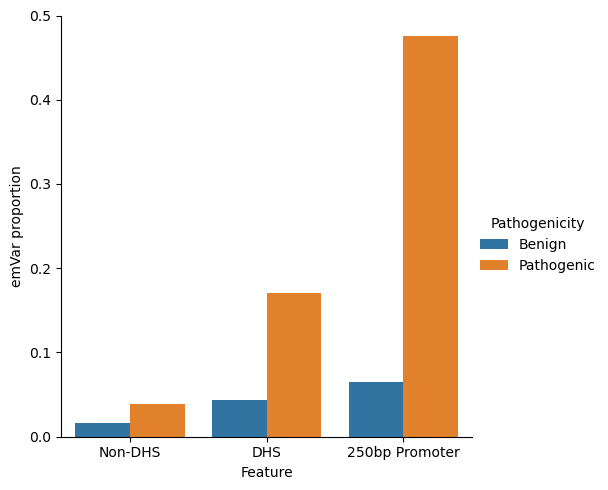

In [34]:
# concatenate proportion DFs for generating bar plot
all_proportions2plot = pd.concat([non_dhs2plot,
                                  dhs2plot,
                                  #dhs_seqlet2plot,
                                  twoFiftyPro2plot]).sort_values(by='Pathogenicity')
# plot proportion of emVars for each feature
# plot in square grid
plt.figure(dpi=300)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# make plot
ax = sns.catplot(data=all_proportions2plot,
            x='Feature',
            y='Proportion',
            hue='Pathogenicity',
            kind='bar')
plt.ylabel('emVar proportion')
#plt.savefig('figures/clinvar_emVar_proportion_fig_2A_basic_filtered.pdf')

In [35]:
all_proportions2plot

,Feature,Proportion,Pathogenicity
1,Non-DHS,0.016722,Benign
1,DHS,0.043270,Benign
1,250bp Promoter,0.064898,Benign
0,Non-DHS,0.038877,Pathogenic
0,DHS,0.170520,Pathogenic
0,250bp Promoter,0.476190,Pathogenic


In [36]:
# define function for performing chi square tests
def perform_chi_square_test(data, col1, col2):
    # Creating a contingency table
    contingency_table = data
    print(contingency_table)
    # Performing the Chi-Square Test
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    # Interpreting the result
    significant = p < 0.05  # 5% significance level
    return chi2, p, significant

In [37]:
# perform chi square tests for each measure
# non dhs
nonDHS_chi2, nonDHS_pVal, nonDHS_sig = perform_chi_square_test(non_dhs_2x2, 'Pathogenic', 'Benign')
# dhs
DHS_chi2, DHS_pVal, DHS_sig = perform_chi_square_test(dhs_2x2, 'Pathogenic', 'Benign')
# promoter
twoFiftyPro_chi2, twoFiftyPro_pVal, twoFiftyPro_sig = perform_chi_square_test(twoFiftyPro_2x2, 'Pathogenic', 'Benign')

           Pathogenic  Benign
emVar              18    2735
non-emVar         445  160820
           Pathogenic  Benign
emVar              59    3785
non-emVar         287   83690
           Pathogenic  Benign
emVar              20     115
non-emVar          22    1657


In [38]:
# describe the number of variants for each group for updating the text/figure
# non-dhs
print('### non-dhs ###')
print(f'there are {list(non_dhs_2x2['Pathogenic'])[0]} pathogenic emvars')
print(f'there are {non_dhs_2x2['Pathogenic'].sum()} total pathogenic variants')
print(f'there are {list(non_dhs_2x2['Benign'])[0]} benign emvars')
print(f'there are {non_dhs_2x2['Benign'].sum()} total benign variants')
# dhs
print('### dhs ###')
print(f'there are {list(dhs_2x2['Pathogenic'])[0]} pathogenic emvars')
print(f'there are {dhs_2x2['Pathogenic'].sum()} total pathogenic variants')
print(f'there are {list(dhs_2x2['Benign'])[0]} benign emvars')
print(f'there are {dhs_2x2['Benign'].sum()} total benign variants')
# promoter
print('### 250bp promoter ###')
print(f'there are {list(twoFiftyPro_2x2['Pathogenic'])[0]} pathogenic emvars')
print(f'there are {twoFiftyPro_2x2['Pathogenic'].sum()} pathogenic variants')
print(f'there are {list(twoFiftyPro_2x2['Benign'])[0]} benign emvars')
print(f'there are {twoFiftyPro_2x2['Benign'].sum()} total benign variants')

### non-dhs ###
there are 18 pathogenic emvars
there are 463 total pathogenic variants
there are 2735 benign emvars
there are 163555 total benign variants
### dhs ###
there are 59 pathogenic emvars
there are 346 total pathogenic variants
there are 3785 benign emvars
there are 87475 total benign variants
### 250bp promoter ###
there are 20 pathogenic emvars
there are 42 pathogenic variants
there are 115 benign emvars
there are 1772 total benign variants


In [39]:
# print the p-values for each test
# non dhs
print('### non-dhs ###')
print(f'the p-value of the chi-square test is {nonDHS_pVal:.2e}')
# dhs
print('### dhs ###')
print(f'the p-value of the chi-square test is {DHS_pVal:.2e}')
# promtoer
print('### 250bp promoter')
print(f'the p-value of the chi-square test is {twoFiftyPro_pVal:.2e}')

### non-dhs ###
the p-value of the chi-square test is 4.24e-04
### dhs ###
the p-value of the chi-square test is 3.51e-30
### 250bp promoter
the p-value of the chi-square test is 2.03e-22


In [40]:
# calculate odds ratios with confidence intervals for each feature (for supplement)
# all clinvar
all_clinvar_OR, all_clinvar_pval = stats.fisher_exact(all_2x2)
all_clinvar_95_ci = stats.contingency.odds_ratio(all_2x2).confidence_interval(0.95)
# DHS
dhs_clinvar_OR, dhs_clinvar_pval = stats.fisher_exact(dhs_2x2)
dhs_clinvar_95_ci = stats.contingency.odds_ratio(dhs_2x2).confidence_interval(0.95)
# 250bp Promoter
twoFifty_clinvar_OR, twoFifty_clinvar_pval = stats.fisher_exact(twoFiftyPro_2x2)
twoFifty_clinvar_95_ci = stats.contingency.odds_ratio(twoFiftyPro_2x2).confidence_interval(0.95)

In [41]:
all_2x2

,Pathogenic,Benign
emVar,77,6520
non-emVar,732,244510


In [42]:
# make a DF for plotting the odds ratios of each feature
OR_df2plot = pd.DataFrame({
    'OddsR' : [all_clinvar_OR, dhs_clinvar_OR, twoFifty_clinvar_OR],
    'lowerCI' : [all_clinvar_95_ci[0], dhs_clinvar_95_ci[0], twoFifty_clinvar_95_ci[0]],
    'upperCI' : [all_clinvar_95_ci[1], dhs_clinvar_95_ci[1], twoFifty_clinvar_95_ci[1]],
    'plot_labs' : ['All ClinVar', 'DHS', '250bp Promoter'],
    'p_val' : [all_clinvar_pval, dhs_clinvar_pval, twoFifty_clinvar_pval]
})
# make a palette for plotting
feature_palette = {'All ClinVar' : '#1b9e77',
                   '250bp Promoter' : '#e7298a',
                   'DHS' : '#66a61e'}

In [43]:
OR_df2plot

,OddsR,lowerCI,upperCI,plot_labs,p_val
0,3.944833,3.073668,5.001201,All ClinVar,8.184291e-22
1,4.545460,3.368093,6.045936,DHS,4.251882e-19
2,13.098814,6.550683,25.894469,250bp Promoter,8.771038e-13


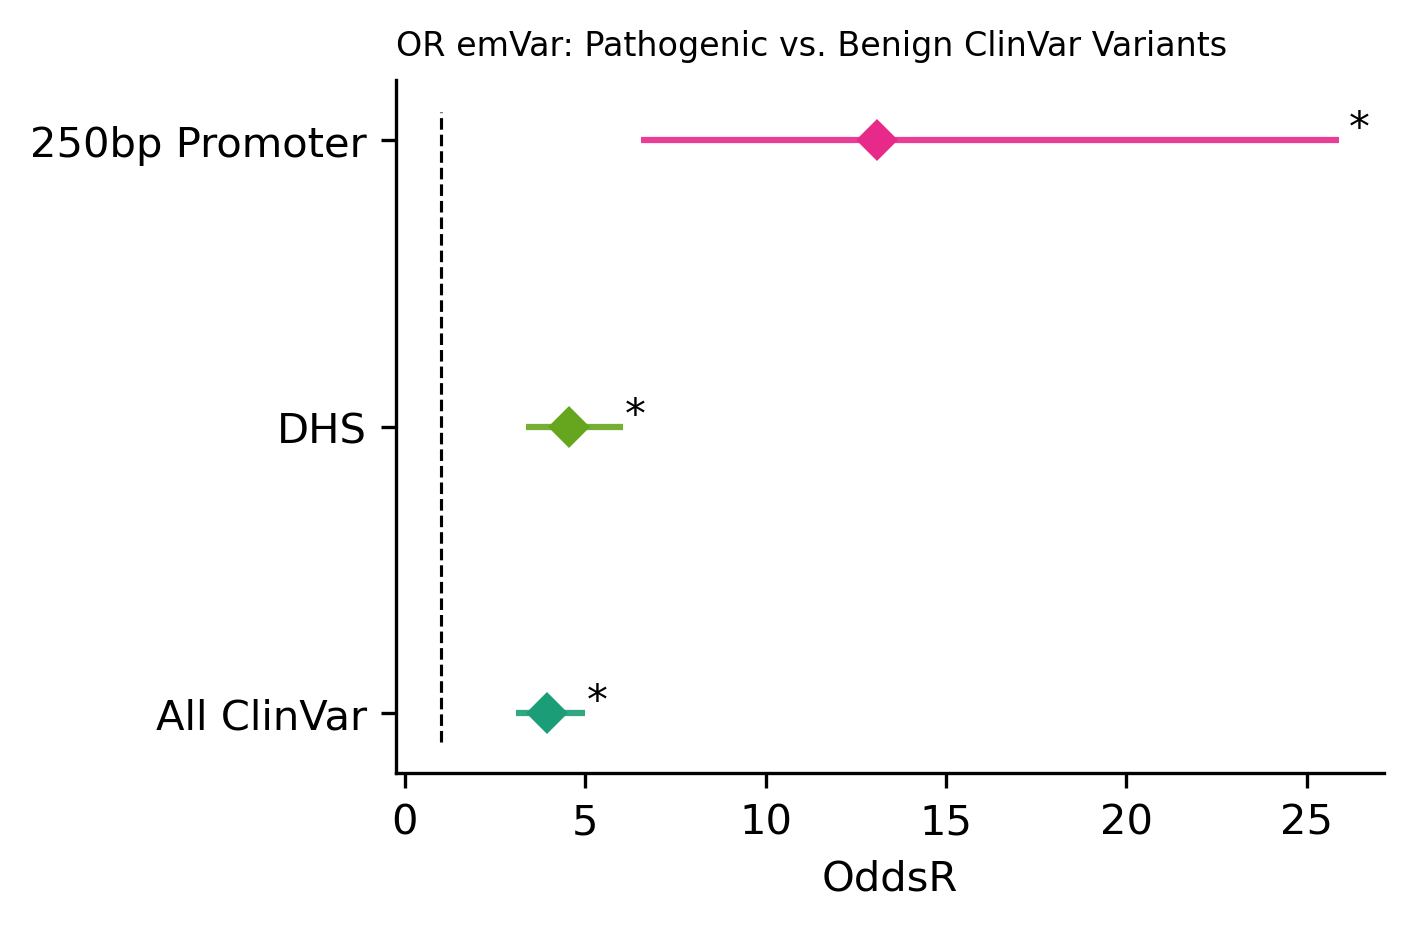

In [44]:
# plot oddsR of emVar in pathogenic vs benign variants by sequence feature #
plt.figure(dpi=300, figsize=(4.25, 3))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plots = sns.pointplot(
        data=OR_df2plot.sort_values(by='OddsR', ascending = False), x="OddsR", y="plot_labs",
        color="#1F271B", linestyle="none", marker="D", markersize=5, hue='plot_labs', palette=feature_palette
)
plt.ylabel('')
for lower, upper, lab, pval in zip(OR_df2plot['lowerCI'],
                                   OR_df2plot['upperCI'],
                                   OR_df2plot['plot_labs'],
                                   OR_df2plot['p_val']):
    plt.hlines(xmin=lower, xmax=upper, y=lab, color=feature_palette.get(lab), alpha=.9)
    if pval < .05:
        plt.annotate('*', xy=(1.01 * upper, lab))
    else:
        continue
ymin, ymax = plots.get_ylim()
plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', linewidth=0.75, linestyle='dashed')
plt.title('OR emVar: Pathogenic vs. Benign ClinVar Variants', loc='left', fontsize=8)
sns.despine()
#plt.savefig('figures/clinvar_OR_emVar_path_v_benign_Supp_Fig_12A_basic_filtered.pdf')

In [45]:
# generate precision recall curves for mpac and sei predictions #
# open SEI predictions
sei_preds = pd.read_csv('raw_data/all_clinvar_20260104_sei_dnase_preds_k562_hepg2_sknsh.tsv',
                        sep = '\t')
# rename name column to id
sei_preds = sei_preds.rename(columns={'name' : 'id'})
# get hepg2 and k562 columns for calculating precision recall
sei_pred_cols = [i for i in sei_preds.keys() if 'K562' in i and 'ENCODE' in i or 'HepG2' in i and 'ENCODE' in i or 'SK-N-SH' in i and 'ENCODE' in i]
# get max prediction for each variant
maxCol = lambda x: max(x.min(), x.max(), key=abs)
sei_preds['sei_max_pred'] = sei_preds.filter(sei_pred_cols).apply(maxCol,
                                                              axis=1)
# filter sei preds for only ENCODE and id
sei_preds = sei_preds.filter(sei_pred_cols + ['id', 'sei_max_pred'])
# merge predictions
mpac_sei_preds = all_clinvar.merge(sei_preds, on='id')

In [46]:
# define function for calculating precision recall at each quantile
def precision_recall_clinvar (all_preds,
                            sei_col,
                            n_tests):
    # filter all clinvar for only pathogenic and benign variants for calculating quantiles
    path_benign = all_preds[all_preds['clinsig'].isin(['Pathogenic',
                                                       'Likely_pathogenic',
                                                       'Benign',
                                                       'Likely_benign'])].copy()
    # make a dictionary for storing sklearn prc measures and metrics
    sei_sklearn_dict = {}
    mpac_no_act_sklearn_dict = {}
    sei_cre_dict = {}
    mpac_cre_dict = {}
    # iterate through columns and annotate hits/misses by quantile
    for test in tqdm(range(n_tests)):
        # split df into pathogenic and benign variants and make matched sample
        # pathogenic
        path_df = all_preds[all_preds['clinsig'].isin(['Pathogenic',
                                                       'Likely_pathogenic'])].copy()
        # add binarized true col
        path_df.loc[:,'emp_true'] = [1 for i in range(len(path_df))]
        # benign
        benign_df = all_preds[all_preds['clinsig'].isin(['Benign',
                                                         'Likely_benign'])].sample(len(path_df))
        # add binarized true col
        benign_df.loc[:,'emp_true'] = [0 for i in range(len(benign_df))]
        # combine into single df
        df2prc = pd.concat([path_df,
                            benign_df])
        ### sei sklearn ### 
        # subset preds for sei cols only
        sei2prc = df2prc.filter(['id',
                                'emp_true',
                                'dhs'] + [sei_col])
        ### take absolute value of max call by sei for calculating sklearn precision recall curve/auc ###
        sei2prc.loc[:,'abs_max'] = [abs(i) for i in sei2prc[sei_col]]
        # calculate precision recall by sklearn metrics
        sei_pre, sei_rec, sei_thresholds = precision_recall_curve(sei2prc['emp_true'],
                                                                  sei2prc['abs_max'])
        sei_auc = metrics.auc(sei_rec,
                              sei_pre)
        # sei_test_N : tuple(precision, recall, thresholds, auc, df)
        sei_sklearn_dict.update({f'sei_test_{test}' : (sei_pre,
                                                             sei_rec,
                                                             sei_thresholds,
                                                             sei_auc,
                                                             sei2prc)})
        ### mpacsklearn ###
        # calculate precision and recall for MPAC
        mpac2prc = df2prc.filter(['id',
                                      'emp_true',
                                      'k562_ref_pred',
                                      'k562_alt_pred',
                                      'hepg2_ref_pred',
                                      'hepg2_alt_pred',
                                      'sknsh_ref_pred',
                                      'sknsh_alt_pred',
                                      'k562_skew_pred',
                                      'hepg2_skew_pred',
                                      'sknsh_skew_pred',
                                      'dhs'])
        # make a copy of mpac2prc for no activity filter calls
        mpac4prc = mpac2prc.copy()
        # use sklearn to calculate auc for no activity considered malinois preds
        mpac4prc.loc[:,'abs_max'] = [abs(max([i,
                                        j,
                                        k], key=abs)) for i,j,k in zip(mpac4prc['k562_skew_pred'],
                                                                       mpac4prc['hepg2_skew_pred'],
                                                                       mpac4prc['sknsh_skew_pred'])]
        mpac_pre, mpac_rec, mpac_thresh = precision_recall_curve(mpac4prc['emp_true'],
                                                                 mpac4prc['abs_max'])
        mpac_no_act_auc = metrics.auc(mpac_rec,
                                     mpac_pre)
        # malinois_test_N : tuple(precsion, recall, thresholds, auc, df)
        mpac_no_act_sklearn_dict.update({f'MPAC_Test_{test}' : (mpac_pre,
                                                                mpac_rec,
                                                                mpac_thresh,
                                                                mpac_no_act_auc,
                                                                mpac4prc)})
        ### SEI + CRE ###
        # refactor skews - set to 0 if variant not in CRE #
        sei2prc.loc[:,'cre_refactor'] = [abs(skew) if dhs == 1 else 0 for dhs, skew in zip(sei2prc['dhs'],
                                                                                     sei2prc['abs_max'])]
        sei_cre_pre, sei_cre_rec, sei_cre_thresh = precision_recall_curve(sei2prc['emp_true'],
                                                                          sei2prc['cre_refactor'])
        sei_cre_pre = sei_cre_pre[1:]
        sei_cre_rec = sei_cre_rec[1:]
        sei_cre_auc= metrics.auc(sei_cre_rec,
                                 sei_cre_pre)
        sei_cre_dict.update({f'sei_CRE_test_{test}' : (sei_cre_pre,
                                                      sei_cre_rec,
                                                      sei_cre_thresh,
                                                      sei_cre_auc,
                                                      sei2prc)})
        ### MPAC + CRE ###
        # refactor skews - set to 0 if variant not in CRE #
        mpac4prc.loc[:,'cre_refactor'] = [abs(skew) if dhs == 1 else 0 for dhs, skew in zip(mpac4prc['dhs'],
                                                                                      mpac4prc['abs_max'])]
        mpac_cre_pre, mpac_cre_rec, mpac_cre_thresh = precision_recall_curve(mpac4prc['emp_true'],
                                                                             mpac4prc['cre_refactor'])
        mpac_cre_pre = mpac_cre_pre[1:]
        mpac_cre_rec = mpac_cre_rec[1:]
        mpac_cre_auc= metrics.auc(mpac_cre_rec,
                                  mpac_cre_pre)
        mpac_cre_dict.update({f'MPAC_CRE_test_{test}' : (mpac_cre_pre,
                                                         mpac_cre_rec,
                                                         mpac_cre_thresh,
                                                         mpac_cre_auc,
                                                         mpac4prc)})
    print(len(path_df))
    print(len(path_benign[path_benign['clinsig'].isin(['Benign', 'Likely_benign'])]))
            
    return sei_sklearn_dict, mpac_no_act_sklearn_dict;

In [47]:
### ALL ###
all_sei_sklearn, mpac_sklearn = precision_recall_clinvar(mpac_sei_preds,
                                                        'sei_max_pred',
                                                        100)

100%|██████████| 100/100 [00:08<00:00, 12.19it/s]


809
251030


In [48]:
### DHS ###
dhs_sei_sklearn, mpac_dhs_sklearn = precision_recall_clinvar(mpac_sei_preds[(mpac_sei_preds['dhs'] == 1)],
                                                            'sei_max_pred',
                                                            100)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:04<00:00, 23.71it/s]

346
87475


In [49]:
### 250bp Promoter ###
pro_sei_sklearn, mpac_pro_sklearn = precision_recall_clinvar(mpac_sei_preds[mpac_sei_preds['250bp_pro'] == 1],
                                                           'sei_max_pred',
                                                           100)

100%|██████████| 100/100 [00:00<00:00, 106.17it/s]

42
1772


In [50]:
### Indels ###
indel_sei_sklearn, indel_mpac_sklearn = precision_recall_clinvar(mpac_sei_preds[mpac_sei_preds['indel'] == 1],
                                                           'sei_max_pred',
                                                           100)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 50.85it/s]

262
29594


In [51]:
### Indels - DHS ###
indel_dhs_sei_sklearn, indel_dhs_mpac_sklearn = precision_recall_clinvar(mpac_sei_preds[(mpac_sei_preds['indel'] == 1) & (mpac_sei_preds['dhs'] == 1)],
                                                           'sei_max_pred',
                                                           100)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 75.75it/s]

129
8123


In [52]:
### Indels - 250bp promoter ###
indel_pro_sei_sklearn, indel_pro_mpac_sklearn = precision_recall_clinvar(mpac_sei_preds[(mpac_sei_preds['indel'] == 1) & (mpac_sei_preds['250bp_pro'] == 1)],
                                                           'sei_max_pred',
                                                           100)

100%|██████████| 100/100 [00:00<00:00, 129.15it/s]

6
252


In [53]:
# define function to concatenate sklearn prc outputs into DF and return plot 
def sklearn_summary_sei_mpac (list_of_dicts,
                    dict_labels,
                    clinvar_feature,
                    path2plot_out,
                    path2summary_out):
    dfs2concat = []
    auc2concat = []
    # iterate through list of dicts and concatenate
    for prc_dict, model in zip(list_of_dicts,
                               dict_labels):
        # concatenate precision/recall data
        df2concat = pd.concat([pd.DataFrame({'Precision' : i[0],
                                             'Recall' : i[1]}) for i in prc_dict.values()])
        # add model label to dictionary for coloring
        df2concat['Model'] = [model for i in range(len(df2concat))]
        # append to list
        dfs2concat.append(df2concat)
        # get average auc
        auc2concat.append(pd.DataFrame({'Model' : [model],
                                        'Mean_AUC' : [np.mean([i[-2] for i in prc_dict.values()])],
                                        'Feature' : [clinvar_feature]}))
    auc_df = pd.concat(auc2concat)
    return auc_df

In [54]:
# make a dictionary for model coloring
model_palette = {'MPAC' : '#9ecae1',
                 'Sei' : '#fd8d3c'}
# make a dict for linestyle
line_palette = {'MPAC' : "solid",
                 'Sei' : 'solid'}
bar_palette = {'MPAC' : '#9ecae1',
               'Sei' : '#fd8d3c'}

In [55]:
# All ClinVar
sklearn_summary_sei_mpac([all_sei_sklearn, mpac_sklearn],
                ['Sei',
                'MPAC'],
                'All ClinVar',
                '',
                '')

,Model,Mean_AUC,Feature
0,Sei,0.614603,All ClinVar
0,MPAC,0.652518,All ClinVar


In [56]:
# ClinVar: DHS
sklearn_summary_sei_mpac([dhs_sei_sklearn,
                 mpac_dhs_sklearn],
                ['Sei',
                'MPAC'],
                'ClinVar: In DHS',
                '',
                '')

,Model,Mean_AUC,Feature
0,Sei,0.650371,ClinVar: In DHS
0,MPAC,0.670547,ClinVar: In DHS


In [57]:
# ClinVar:250bp Promoter
sklearn_summary_sei_mpac([pro_sei_sklearn, 
                 mpac_pro_sklearn],
                ['Sei',
                'MPAC'],
                'ClinVar: In 250bp Promoter',
                '',
                '')

,Model,Mean_AUC,Feature
0,Sei,0.758497,ClinVar: In 250bp Promoter
0,MPAC,0.820455,ClinVar: In 250bp Promoter


In [58]:
# Indel
sklearn_summary_sei_mpac([indel_sei_sklearn, 
                 indel_mpac_sklearn],
                ['Sei',
                'MPAC'],
                'ClinVar: Indel',
                '',
                '')

,Model,Mean_AUC,Feature
0,Sei,0.610012,ClinVar: Indel
0,MPAC,0.685101,ClinVar: Indel


In [59]:
# Indel in HDS
sklearn_summary_sei_mpac([indel_dhs_sei_sklearn, 
                 indel_dhs_mpac_sklearn],
                ['Sei',
                'MPAC'],
                'ClinVar: Indel in DHS',
                '',
                '')

,Model,Mean_AUC,Feature
0,Sei,0.586827,ClinVar: Indel in DHS
0,MPAC,0.675305,ClinVar: Indel in DHS


In [60]:
# Indel in Promoter
sklearn_summary_sei_mpac([indel_pro_sei_sklearn, 
                 indel_pro_mpac_sklearn],
                ['Sei',
                'MPAC'],
                'ClinVar: Indel in 250bp Promoter',
                '',
                '')

,Model,Mean_AUC,Feature
0,Sei,0.682705,ClinVar: Indel in 250bp Promoter
0,MPAC,0.928646,ClinVar: Indel in 250bp Promoter


In [61]:
# define function to concatenate sklearn prc outputs into DF and return plot 
def sklearn_4_grid (list_of_dicts,
                    dict_labels,
                    clinvar_feature,
                    path2summary_out):
    dfs2concat = []
    auc2concat = []
    # iterate through list of dicts and concatenate
    for prc_dict, model in zip(list_of_dicts,
                               dict_labels):
        # concatenate precision/recall data
        df2concat = pd.concat([pd.DataFrame({'Precision' : i[0],
                                             'Recall' : i[1]}) for i in prc_dict.values()])
        # add model label to dictionary for coloring
        df2concat['Model'] = [model for i in range(len(df2concat))]
        # append to list
        dfs2concat.append(df2concat)
        # get 95% CIs
        lowerCI, upperCI = stats.t.interval(0.95, len([i[-2] for i in prc_dict.values()])-1, 
                                          loc=np.mean([i[-2] for i in prc_dict.values()]), 
                                          scale=stats.sem([i[-2] for i in prc_dict.values()]))
        # get average auc
        auc2concat.append(pd.DataFrame({'Model' : [model],
                                        'Mean_AUC' : [np.mean([i[-2] for i in prc_dict.values()])],
                                        'lower_CI' : [lowerCI],
                                        'upper_CI' : [upperCI],
                                        'Feature' : [clinvar_feature]}))
    auc_df = pd.concat(auc2concat)
    # save to disk
    #auc_df.to_csv(path2summary_out,
    #              sep = '\t',
    #              index = False)
    df2return = pd.concat(dfs2concat)
    return df2return, auc_df

In [62]:
# reformat DF for plotting in a grid like we had in the figure before
# also return the DF for plotting the Bar plot f mean AUC
# All ClinVar
all_4_grid, all_auc_df = sklearn_4_grid([all_sei_sklearn,
                             mpac_sklearn],
                            ['Sei',
                             'MPAC'],
                             'All ClinVar',
                             '')
# DHS
dhs_4_grid, dhs_auc_df = sklearn_4_grid([dhs_sei_sklearn,
                                        mpac_dhs_sklearn],
                                        ['Sei',
                                        'MPAC'],
                                        'ClinVar: In DHS',
                                        '')
# 250bp promoter
twoFifty_4_grid, twoFifty_auc_df = sklearn_4_grid([pro_sei_sklearn, 
                                                   mpac_pro_sklearn],
                                                  ['Sei',
                                                  'MPAC'],
                                                  'ClinVar: In 250bp Promoter',
                                                  '')

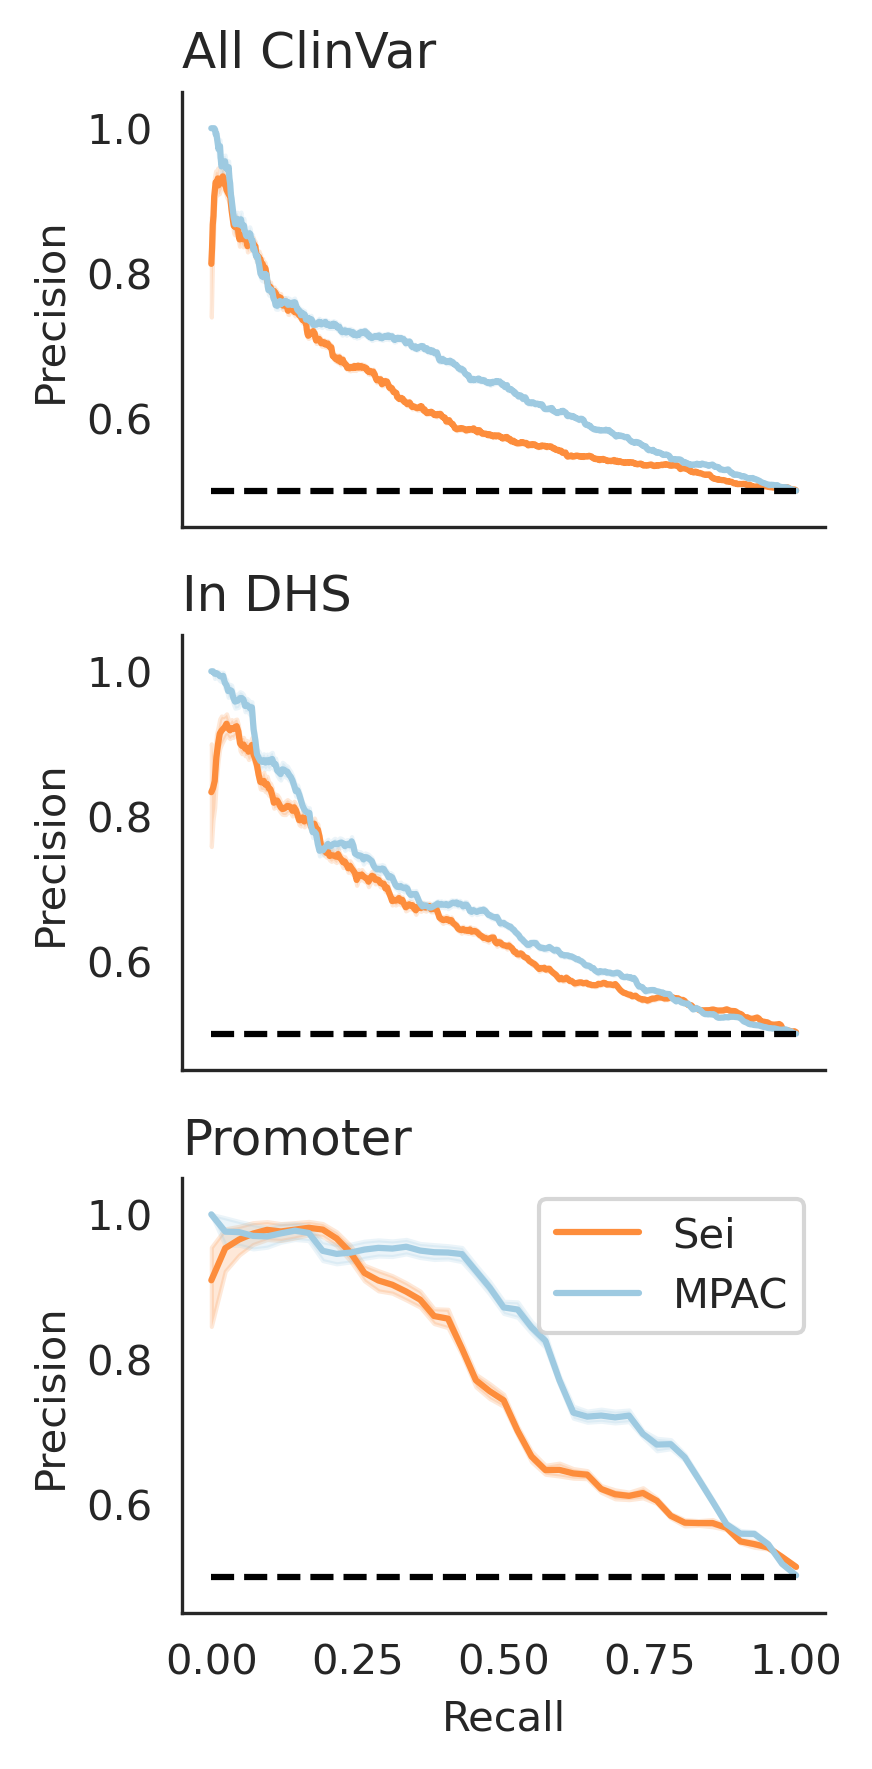

In [63]:
# plot in square grid
f = plt.figure(figsize=(3, 6), dpi=300)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(3,1)
# Plot All ClinVar
with sns.axes_style("white"):
    ax_01 = f.add_subplot(gs[0,0])
    sns.lineplot(data=all_4_grid,
                 x='Recall',
                 y='Precision',
                 hue='Model',
                 palette=model_palette,
                 rasterized=True,
                 legend=False)
    plt.title('All ClinVar', loc='left')
    plt.hlines(y=.5,
               xmin=0,
               xmax=1,
               color='k',
               linestyles='dashed')
    plt.ylim(.45, 1.05)
    plt.xlabel('')
    plt.xticks([])
# Plot in DHS
with sns.axes_style("white"):
    ax_02 = f.add_subplot(gs[1,0])
    sns.lineplot(data=dhs_4_grid,
                 x='Recall',
                 y='Precision',
                 hue='Model',
                 palette=model_palette,
                 rasterized=True,
                 legend=False)
    plt.title('In DHS', loc='left')
    plt.hlines(y=.5,
               xmin=0,
               xmax=1,
               color='k',
               linestyles='dashed')
    plt.ylim(.45, 1.05)
    plt.xlabel('')
    plt.xticks([])
# Plot in 250bp Promoter
with sns.axes_style("white"):
    ax_03 = f.add_subplot(gs[2,0])
    sns.lineplot(data=twoFifty_4_grid,
                 x='Recall',
                 y='Precision',
                 hue='Model',
                 palette=model_palette,
                 rasterized=True,
                 legend=True)
    plt.title('Promoter', loc='left')
    plt.hlines(y=.5,
               xmin=0,
               xmax=1,
               color='k',
               linestyles='dashed')
    plt.legend(loc='upper right')
    plt.ylim(.45, 1.05)
plt.tight_layout()
sns.despine()
#plt.savefig('figures/clinvar_prc_curves_fig_2B_basic_filtered.pdf')

  Model  Mean_AUC  lower_CI  upper_CI                     Feature
0   Sei  0.614603  0.612542  0.616664                 All ClinVar
0  MPAC  0.652518  0.650527  0.654508                 All ClinVar
0   Sei  0.650371  0.647101  0.653641             ClinVar: In DHS
0  MPAC  0.670547  0.667685  0.673410             ClinVar: In DHS
0   Sei  0.758497  0.751640  0.765354  ClinVar: In 250bp Promoter
0  MPAC  0.820455  0.814203  0.826707  ClinVar: In 250bp Promoter


<Figure size 1200x1800 with 0 Axes>

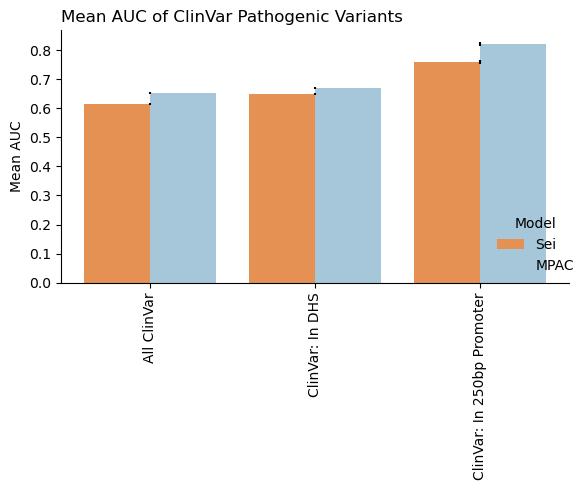

In [64]:
# combine all mean AUCs for bar plot of mean AUC with confidence intervals
mean_auc2plot = pd.concat([all_auc_df, dhs_auc_df, twoFifty_auc_df])

print(mean_auc2plot)
# make a bar plot of above mean AUCs
plt.figure(dpi=300, figsize=(4,6))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
sns.catplot(data=mean_auc2plot,
            x='Feature',
            y='Mean_AUC',
            hue='Model',
            palette=bar_palette,
            kind='bar')
for lower, upper, lab in zip(mean_auc2plot['lower_CI'],
                            mean_auc2plot['upper_CI'],
                            mean_auc2plot['Feature']):
    plt.vlines(x=lab, ymin=lower, ymax=upper, color='k')
plt.xticks(rotation=90)
plt.ylabel('Mean AUC')
plt.xlabel('')
plt.title('Mean AUC of ClinVar Pathogenic Variants', loc='left')
plt.tight_layout()
#plt.savefig('figures/clinvar_auc_Supp_Fig_12B_basic_filtered.pdf')

In [65]:
# plot prcs for indels only
# All ClinVar
all_4_grid_indel, all_auc_df_indel = sklearn_4_grid([indel_sei_sklearn,
                             indel_mpac_sklearn],
                            ['Sei',
                             'MPAC'],
                             'All ClinVar: Indels Only',
                             '')
# DHS
dhs_4_grid_indel, dhs_auc_df_indel = sklearn_4_grid([indel_dhs_sei_sklearn,
                                        indel_dhs_mpac_sklearn],
                                        ['Sei',
                                        'MPAC'],
                                        'ClinVar: In DHS, Indel Only',
                                        '')
# 250bp promoter
twoFifty_4_grid_indel, twoFifty_auc_df_indel = sklearn_4_grid([indel_pro_sei_sklearn, 
                                                   indel_pro_mpac_sklearn],
                                                  ['Sei',
                                                  'MPAC'],
                                                  'ClinVar: In 250bp Promoter, Indels Only',
                                                  '')

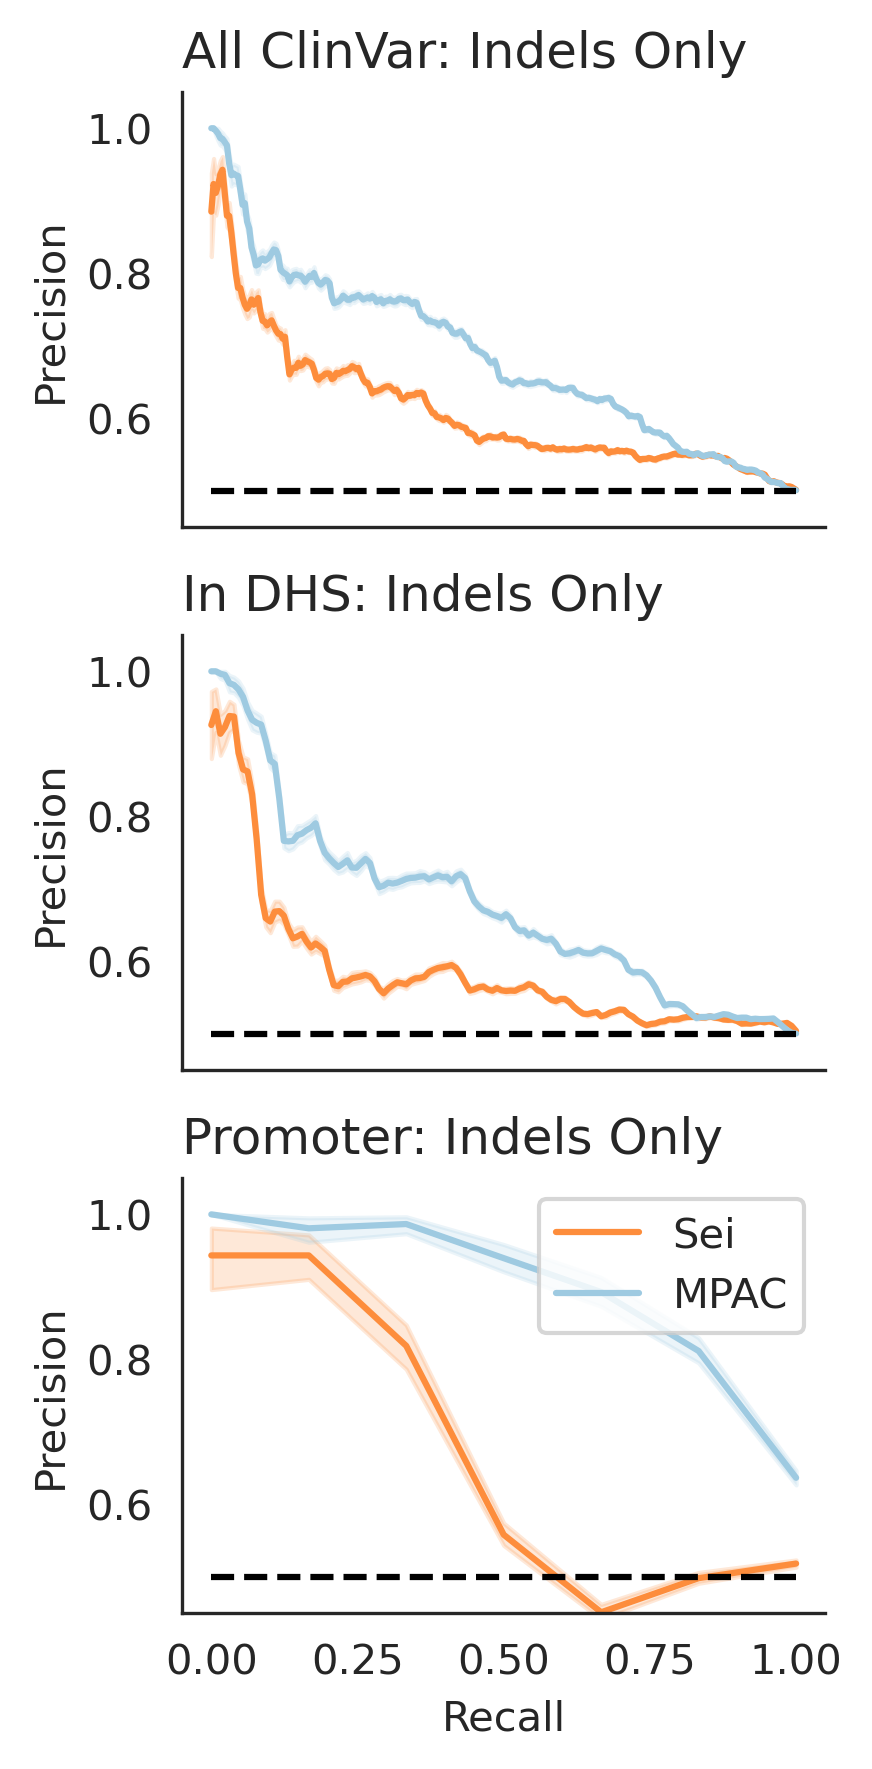

In [66]:
# plot in square grid
f = plt.figure(figsize=(3, 6), dpi=300)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(3,1)
# Plot All ClinVar
with sns.axes_style("white"):
    ax_01 = f.add_subplot(gs[0,0])
    sns.lineplot(data=all_4_grid_indel,
                 x='Recall',
                 y='Precision',
                 hue='Model',
                 palette=model_palette,
                 #rasterized=True,
                 legend=False)
    plt.title('All ClinVar: Indels Only', loc='left')
    plt.hlines(y=.5,
               xmin=0,
               xmax=1,
               color='k',
               linestyles='dashed')
    plt.ylim(.45, 1.05)
    plt.xlabel('')
    plt.xticks([])
# Plot in DHS
with sns.axes_style("white"):
    ax_02 = f.add_subplot(gs[1,0])
    sns.lineplot(data=dhs_4_grid_indel,
                 x='Recall',
                 y='Precision',
                 hue='Model',
                 palette=model_palette,
                 #rasterized=True,
                 legend=False)
    plt.title('In DHS: Indels Only', loc='left')
    plt.hlines(y=.5,
               xmin=0,
               xmax=1,
               color='k',
               linestyles='dashed')
    plt.ylim(.45, 1.05)
    plt.xlabel('')
    plt.xticks([])
# Plot in 250bp Promoter
with sns.axes_style("white"):
    ax_03 = f.add_subplot(gs[2,0])
    sns.lineplot(data=twoFifty_4_grid_indel,
                 x='Recall',
                 y='Precision',
                 hue='Model',
                 palette=model_palette,
                 #rasterized=True,
                 legend=True)
    plt.title('Promoter: Indels Only', loc='left')
    plt.hlines(y=.5,
               xmin=0,
               xmax=1,
               color='k',
               linestyles='dashed')
    plt.legend(loc='upper right')
    plt.ylim(.45, 1.05)
plt.tight_layout()
sns.despine()
#plt.savefig('figures/clinvar_prc_curves_indels_only_Supp_fig_12C_basic_filtered.pdf')

  Model  Mean_AUC  lower_CI  upper_CI                                  Feature
0   Sei  0.610012  0.606364  0.613660                 All ClinVar: Indels Only
0  MPAC  0.685101  0.681588  0.688615                 All ClinVar: Indels Only
0   Sei  0.586827  0.582422  0.591231              ClinVar: In DHS, Indel Only
0  MPAC  0.675305  0.671159  0.679451              ClinVar: In DHS, Indel Only
0   Sei  0.682705  0.668969  0.696441  ClinVar: In 250bp Promoter, Indels Only
0  MPAC  0.928646  0.917728  0.939564  ClinVar: In 250bp Promoter, Indels Only


<Figure size 1200x1800 with 0 Axes>

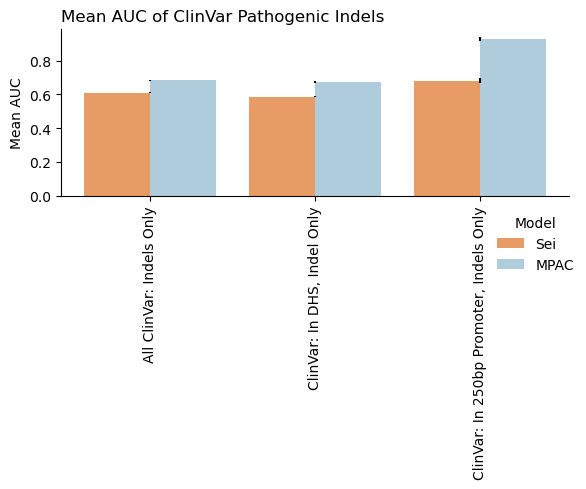

In [67]:
# combine all mean AUCs for bar plot of mean AUC with confidence intervals
mean_auc2plot_indels = pd.concat([all_auc_df_indel, dhs_auc_df_indel, twoFifty_auc_df_indel])

print(mean_auc2plot_indels)
# make a bar plot of above mean AUCs
plt.figure(dpi=300, figsize=(4,6))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
sns.catplot(data=mean_auc2plot_indels,
            x='Feature',
            y='Mean_AUC',
            hue='Model',
            palette=bar_palette,
            kind='bar',
            # edgecolor='slategray',
            # hatch='|',
            alpha=0.90)
for lower, upper, lab in zip(mean_auc2plot_indels['lower_CI'],
                             mean_auc2plot_indels['upper_CI'],
                             mean_auc2plot_indels['Feature']):
    plt.vlines(x=lab, ymin=lower, ymax=upper, color='k')
plt.xticks(rotation=90)
plt.ylabel('Mean AUC')
plt.xlabel('')
plt.title('Mean AUC of ClinVar Pathogenic Indels', loc='left')
plt.tight_layout()
#plt.savefig('figures/clinvar_auc_indels_only_Supp_Fig_12D_basic_filtered.pdf')

In [68]:
# define a function for calculating mean precision at empirical recall #
def get_mpac_pre_at_recall (empirical_recall,
                            pre_rec_dict):
    # make list of precisions
    pre_list = [list(pre_rec_dict.get(i)[0]) for i in pre_rec_dict.keys()]
    # make list of recalls
    rec_list = [list(pre_rec_dict.get(i)[1]) for i in pre_rec_dict.keys()]
    # iterate through list of of recalls and get indices of recalls in the emprical range
    emp_upper = empirical_recall * 1.01
    emp_lower = empirical_recall * .99
    # get indices
    precisions = []
    for recall_list, precision_list in zip(rec_list, pre_list):
        # update indices list with the recalls in the range of these values
        indices = [i for i,j in enumerate(recall_list) if j > emp_lower and j < emp_upper]
        # append mean precision at those recalls to list
        precisions.append(np.mean(precision_list[min(indices):max(indices)+1]))
    mean_precision = np.mean(precisions)
    print(f'The mean MPAC precision at the empirical recall: {empirical_recall} is {mean_precision}')
    return mean_precision

In [69]:
get_mpac_pre_at_recall(empDHS_recall,
                       mpac_sklearn)

The mean MPAC precision at the empirical recall: 0.4276885043263288 is 0.667563717586816


np.float64(0.667563717586816)

In [70]:
# save the pathogenic/benign variants to disk as a bed file for intersecting with seqlet calls downstream
# make a bed of pathogenic and benign ids
chrom4bed = []
start4bed = []
end4bed = []
id4bed = []
for chrom, pos, id, ref, alt in zip(path_benign_preds['chrom'], 
                                    path_benign_preds['pos'], 
                                    path_benign_preds['id'], 
                                    path_benign_preds['ref'], 
                                    path_benign_preds['alt']):
    # update chromosome and id lists
    chrom4bed.append(chrom)
    id4bed.append(id)
    # check the length of the variant for generating the start and stop intervals
    if len(ref) == 1 and len(alt) == 1: # SNPs
        start4bed.append(pos - 1)
        end4bed.append(pos)
    elif len(ref) < len(alt): # Insertions
        start4bed.append(pos)
        end4bed.append(pos)
    else: # Deletions
        start4bed.append(pos)
        end4bed.append(pos + len(ref) - 1)
    
path_benign_clinvar_bed = pybedtools.BedTool.from_dataframe(pd.DataFrame({0 : chrom4bed,
                                                                          1 : start4bed,
                                                                          2 : end4bed,
                                                                          3 : id4bed}).drop_duplicates()).sort()
# save to disk
#path_benign_clinvar_bed.to_dataframe().to_csv('processed_data/clinvar_pathogenic_and_benign_variants_basic_filtered.bed', sep = '\t', index = False, header = None)

In [71]:
# calculate the precision/recall in unbalanced sets
# define function for calculating precision recall at each quantile
def precision_recall_clinvar_no_balance (all_preds,
                                         sei_col,
                                         n_tests):
    # filter all clinvar for only pathogenic and benign variants for calculating quantiles
    path_benign = all_preds[all_preds['clinsig'].isin(['Pathogenic',
                                                       'Likely_pathogenic',
                                                       'Benign',
                                                       'Likely_benign'])].copy()
    # make a dictionary for storing sklearn prc measures and metrics
    sei_sklearn_dict = {}
    mpac_no_act_sklearn_dict = {}
    sei_cre_dict = {}
    mpac_cre_dict = {}
    # iterate through columns and annotate hits/misses by quantile
    for test in tqdm(range(n_tests)):
        # split df into pathogenic and benign variants and make matched sample
        # pathogenic
        path_df = all_preds[all_preds['clinsig'].isin(['Pathogenic',
                                                       'Likely_pathogenic'])].copy()
        # add binarized true col
        path_df.loc[:,'emp_true'] = [1 for i in range(len(path_df))]
        # benign
        benign_df = all_preds[all_preds['clinsig'].isin(['Benign',
                                                         'Likely_benign'])].copy()
        # add binarized true col
        benign_df.loc[:,'emp_true'] = [0 for i in range(len(benign_df))]
        # combine into single df
        df2prc = pd.concat([path_df,
                            benign_df])
        ### sei sklearn ### 
        # subset preds for sei cols only
        sei2prc = df2prc.filter(['id',
                                'emp_true',
                                'dhs'] + [sei_col])
        ### take absolute value of max call by sei for calculating sklearn precision recall curve/auc ###
        sei2prc.loc[:,'abs_max'] = [abs(i) for i in sei2prc[sei_col]]
        # calculate precision recall by sklearn metrics
        sei_pre, sei_rec, sei_thresholds = precision_recall_curve(sei2prc['emp_true'],
                                                                  sei2prc['abs_max'])
        sei_auc = metrics.auc(sei_rec,
                              sei_pre)
        # sei_test_N : tuple(precision, recall, thresholds, auc, df)
        sei_sklearn_dict.update({f'sei_test_{test}' : (sei_pre,
                                                             sei_rec,
                                                             sei_thresholds,
                                                             sei_auc,
                                                             sei2prc)})
        ### mpacsklearn ###
        # calculate precision and recall for MPAC
        mpac2prc = df2prc.filter(['id',
                                      'emp_true',
                                      'k562_ref_pred',
                                      'k562_alt_pred',
                                      'hepg2_ref_pred',
                                      'hepg2_alt_pred',
                                      'sknsh_ref_pred',
                                      'sknsh_alt_pred',
                                      'k562_skew_pred',
                                      'hepg2_skew_pred',
                                      'sknsh_skew_pred',
                                      'dhs'])
        # make a copy of mpac2prc for no activity filter calls
        mpac4prc = mpac2prc.copy()
        # use sklearn to calculate auc for no activity considered malinois preds
        mpac4prc.loc[:,'abs_max'] = [abs(max([i,
                                        j,
                                        k], key=abs)) for i,j,k in zip(mpac4prc['k562_skew_pred'],
                                                                       mpac4prc['hepg2_skew_pred'],
                                                                       mpac4prc['sknsh_skew_pred'])]
        mpac_pre, mpac_rec, mpac_thresh = precision_recall_curve(mpac4prc['emp_true'],
                                                                 mpac4prc['abs_max'])
        mpac_no_act_auc = metrics.auc(mpac_rec,
                                     mpac_pre)
        # malinois_test_N : tuple(precsion, recall, thresholds, auc, df)
        mpac_no_act_sklearn_dict.update({f'MPAC_Test_{test}' : (mpac_pre,
                                                                mpac_rec,
                                                                mpac_thresh,
                                                                mpac_no_act_auc,
                                                                mpac4prc)})
        ### SEI + CRE ###
        # refactor skews - set to 0 if variant not in CRE #
        sei2prc.loc[:,'cre_refactor'] = [abs(skew) if dhs == 1 else 0 for dhs, skew in zip(sei2prc['dhs'],
                                                                                     sei2prc['abs_max'])]
        sei_cre_pre, sei_cre_rec, sei_cre_thresh = precision_recall_curve(sei2prc['emp_true'],
                                                                          sei2prc['cre_refactor'])
        sei_cre_pre = sei_cre_pre[1:]
        sei_cre_rec = sei_cre_rec[1:]
        sei_cre_auc= metrics.auc(sei_cre_rec,
                                 sei_cre_pre)
        sei_cre_dict.update({f'sei_CRE_test_{test}' : (sei_cre_pre,
                                                      sei_cre_rec,
                                                      sei_cre_thresh,
                                                      sei_cre_auc,
                                                      sei2prc)})
        ### MPAC + CRE ###
        # refactor skews - set to 0 if variant not in CRE #
        mpac4prc.loc[:,'cre_refactor'] = [abs(skew) if dhs == 1 else 0 for dhs, skew in zip(mpac4prc['dhs'],
                                                                                      mpac4prc['abs_max'])]
        mpac_cre_pre, mpac_cre_rec, mpac_cre_thresh = precision_recall_curve(mpac4prc['emp_true'],
                                                                             mpac4prc['cre_refactor'])
        mpac_cre_pre = mpac_cre_pre[1:]
        mpac_cre_rec = mpac_cre_rec[1:]
        mpac_cre_auc= metrics.auc(mpac_cre_rec,
                                  mpac_cre_pre)
        mpac_cre_dict.update({f'MPAC_CRE_test_{test}' : (mpac_cre_pre,
                                                         mpac_cre_rec,
                                                         mpac_cre_thresh,
                                                         mpac_cre_auc,
                                                         mpac4prc)})
    print(len(path_df))
    print(len(path_benign[path_benign['clinsig'].isin(['Benign', 'Likely_benign'])]))
            
    return sei_sklearn_dict, mpac_no_act_sklearn_dict;

In [72]:
# calculate the unabalanced performance on all
all_sei_sklearn_ub, mpac_sklearn_ub = precision_recall_clinvar_no_balance(mpac_sei_preds,
                                                                    'sei_max_pred',
                                                                    100)
### DHS ###
dhs_sei_sklearn_ub, mpac_dhs_sklearn_ub = precision_recall_clinvar_no_balance(mpac_sei_preds[mpac_sei_preds['dhs'] == 1].copy(),
                                                            'sei_max_pred',
                                                            100)
### 250bp Promoter ###
pro_sei_sklearn_ub, mpac_pro_sklearn_ub = precision_recall_clinvar_no_balance(mpac_sei_preds[mpac_sei_preds['250bp_pro'] == 1],
                                                           'sei_max_pred',
                                                           100)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [01:39<00:00,  1.00it/s]


809
251030


100%|██████████| 100/100 [00:35<00:00,  2.80it/s]


346
87475


100%|██████████| 100/100 [00:01<00:00, 71.93it/s]

42
1772


In [73]:
# summarize unbalanced performance
# All ClinVar (unbalanced)
sklearn_summary_sei_mpac([all_sei_sklearn_ub, 
                          mpac_sklearn_ub],
                ['Sei',
                'MPAC'],
                'All ClinVar',
                '',
                '')

,Model,Mean_AUC,Feature
0,Sei,0.006602,All ClinVar
0,MPAC,0.012339,All ClinVar


In [74]:
# ClinVar: DHS (unbalanced)
sklearn_summary_sei_mpac([dhs_sei_sklearn_ub,
                 mpac_dhs_sklearn_ub],
                ['Sei',
                'MPAC'],
                'ClinVar: In DHS',
                '',
                '')

,Model,Mean_AUC,Feature
0,Sei,0.010147,ClinVar: In DHS
0,MPAC,0.024339,ClinVar: In DHS


In [75]:
# ClinVar:250bp Promoter (unbalanced)
sklearn_summary_sei_mpac([pro_sei_sklearn_ub, 
                 mpac_pro_sklearn_ub],
                ['Sei',
                'MPAC'],
                'ClinVar: In 250bp Promoter',
                '',
                '')

,Model,Mean_AUC,Feature
0,Sei,0.153179,ClinVar: In 250bp Promoter
0,MPAC,0.203123,ClinVar: In 250bp Promoter


In [76]:
# reformat DF for plotting in a grid like we had in the figure before
# also return the DF for plotting the Bar plot f mean AUC
# All ClinVar
all_4_grid_ub, all_auc_df_ub = sklearn_4_grid([all_sei_sklearn_ub,
                             mpac_sklearn_ub],
                            ['Sei',
                             'MPAC'],
                             'All ClinVar',
                             '')
# DHS
dhs_4_grid_ub, dhs_auc_df_ub = sklearn_4_grid([dhs_sei_sklearn_ub,
                                        mpac_dhs_sklearn_ub],
                                        ['Sei',
                                        'MPAC'],
                                        'ClinVar: In DHS',
                                        '')
# 250bp promoter
twoFifty_4_grid_ub, twoFifty_auc_df_ub = sklearn_4_grid([pro_sei_sklearn_ub, 
                                                   mpac_pro_sklearn_ub],
                                                  ['Sei',
                                                  'MPAC'],
                                                  'ClinVar: In 250bp Promoter',
                                                  '')

/projects/tewhey-lab/buttsj/miniforge3/envs/block_calling/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/projects/tewhey-lab/buttsj/miniforge3/envs/block_calling/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
/projects/tewhey-lab/buttsj/miniforge3/envs/block_calling/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/projects/tewhey-lab/buttsj/miniforge3/envs/block_calling/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


  Model  Mean_AUC  lower_CI  upper_CI                     Feature
0   Sei  0.006602       NaN       NaN                 All ClinVar
0  MPAC  0.012339  0.012339  0.012339                 All ClinVar
0   Sei  0.010147  0.010147  0.010147             ClinVar: In DHS
0  MPAC  0.024339  0.024339  0.024339             ClinVar: In DHS
0   Sei  0.153179       NaN       NaN  ClinVar: In 250bp Promoter
0  MPAC  0.203123  0.203123  0.203123  ClinVar: In 250bp Promoter


<Figure size 1200x1800 with 0 Axes>

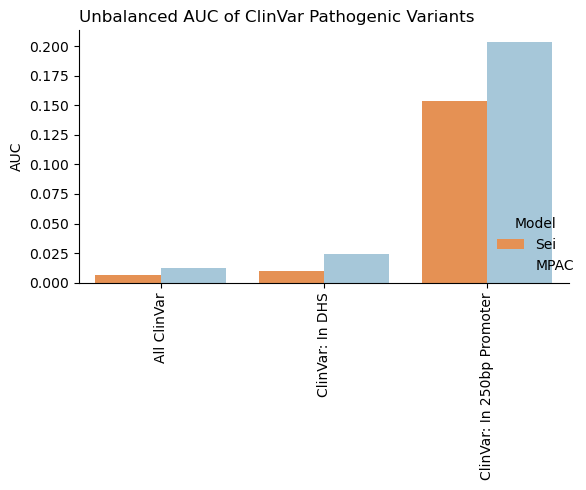

In [77]:
# combine all mean AUCs for bar plot of mean AUC with confidence intervals
mean_auc2plot_ub = pd.concat([all_auc_df_ub, dhs_auc_df_ub, twoFifty_auc_df_ub])

print(mean_auc2plot_ub)
# make a bar plot of above mean AUCs
plt.figure(dpi=300, figsize=(4,6))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
sns.catplot(data=mean_auc2plot_ub,
            x='Feature',
            y='Mean_AUC',
            hue='Model',
            palette=bar_palette,
            kind='bar')
# for lower, upper, lab in zip(mean_auc2plot['lower_CI'],
#                             mean_auc2plot['upper_CI'],
#                             mean_auc2plot['Feature']):
#     plt.vlines(x=lab, ymin=lower, ymax=upper, color='k')
plt.xticks(rotation=90)
plt.ylabel('AUC')
plt.xlabel('')
plt.title('Unbalanced AUC of ClinVar Pathogenic Variants', loc='left')
plt.tight_layout()
#plt.savefig('figures/clinvar_auc_unbalanced_Supp_Fig_12D_basic_filtered.pdf')

In [78]:
# save pathogenic/benign predictions for other analyses
path_benign_preds.to_csv('processed_data/clinvar_20260314_pathogenic_and_benign_preds.tsv', sep = '\t', index = False)